In [4]:
from pyspark import SparkConf
from pyspark.sql import SparkSession

In [8]:
conf = (SparkConf()
            .setMaster("yarn")
            .set("spark.executor.cores", 5)
            .set("spark.sql.shuffle.partitions", 200)
            .set("spark.default.parallelism", 200)
            .set("spark.executor.memory", "7g")
            .set("spark.dynamicAllocation.maxExecutors", 20)
        )

spark = SparkSession \
    .builder \
    .config(conf=conf) \
    .appName("Test_PySpark") \
    .getOrCreate()

In [10]:
# Ejemplo de creación de un DataFrame a partir de los datos almacenados en HDFS
df = spark.read \
          .option("header","true") \
          .option("inferSchema", "true") \
          .csv("/datos/gittba26/gittba03/bronce")

In [11]:
df.printSchema()

root
 |-- event_time: timestamp (nullable = true)
 |-- timeframe: double (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: double (nullable = true)
 |-- source: string (nullable = true)
 |-- ingestion_time: timestamp (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)



In [14]:
from pyspark.sql import functions as F

bronze_path = "hdfs:///datos/gittba26/gittba03/bronce"
silver_path = "hdfs:///datos/gittba26/gittba03/plata"

df = spark.read \
    .option("header","true") \
    .option("inferSchema", "true") \
    .csv(bronze_path)

df_silver = (
    df
    .select("event_time", "open", "high", "low", "close", "volume", "month", "year")  # ❌ quitamos timeframe
    .withColumn("event_time", F.to_timestamp("event_time"))
    .withColumn("open", F.col("open").cast("double"))
    .withColumn("high", F.col("high").cast("double"))
    .withColumn("low", F.col("low").cast("double"))
    .withColumn("close", F.col("close").cast("double"))
    .withColumn("volume", F.col("volume").cast("double"))
)

print("Filas leídas:", df_silver.count())

(df_silver
 .write
 .mode("overwrite")
 .partitionBy("year", "month")
 .parquet(silver_path)
)

Filas leídas: 1461


In [23]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

silver_path = "hdfs:///datos/gittba26/gittba03/plata"
gold_path   = "hdfs:///datos/gittba26/gittba03/oro"

df = spark.read.parquet(silver_path)

# 1) Asegura orden estable y crea índice por fila
w = Window.orderBy("event_time")
df_idx = df.withColumn("idx", (F.row_number().over(w) - 1).cast("int"))

# 2) SMA200 (nativo con window de 200 filas)
w200 = w.rowsBetween(-199, 0)
df_idx = df_idx.withColumn("sma_200", F.avg("close").over(w200))

# 3) Construye arrays ordenados (close y también idx para re-unir)
series = (
    df_idx
    .select(F.struct("idx", "close").alias("s"))
    .agg(F.sort_array(F.collect_list("s")).alias("arr"))
    .select(
        F.expr("transform(arr, x -> x.idx)").alias("idx_arr"),
        F.expr("transform(arr, x -> double(x.close))").alias("close_arr")
    )
)

alpha50 = 2.0 / (50.0 + 1.0)
alpha12 = 2.0 / (12.0 + 1.0)
alpha26 = 2.0 / (26.0 + 1.0)
alpha9  = 2.0 / (9.0  + 1.0)
alpha_rsi = 1.0 / 14.0  # Wilder

# Helper SQL expr: EMA array recursiva sobre un array
def ema_array_expr(arr_col: str, alpha: float) -> str:
    return f"""
    aggregate(
      slice({arr_col}, 2, size({arr_col})-1),
      array(element_at({arr_col}, 1)),
      (acc, x) -> concat(acc, array({alpha}*x + (1-{alpha})*element_at(acc, -1)))
    )
    """

# 4) Calcula EMA50, EMA12, EMA26, MACD, SIGNAL(9), RSI14 (todo nativo)
series_ind = (
    series
    # EMA50
    .withColumn("ema50_arr", F.expr(ema_array_expr("close_arr", alpha50)))
    # EMA12 / EMA26
    .withColumn("ema12_arr", F.expr(ema_array_expr("close_arr", alpha12)))
    .withColumn("ema26_arr", F.expr(ema_array_expr("close_arr", alpha26)))
    # MACD = ema12 - ema26
    .withColumn("macd_arr", F.expr("transform(sequence(1, size(close_arr)), i -> element_at(ema12_arr,i) - element_at(ema26_arr,i))"))
    # SIGNAL = EMA9(macd)
    .withColumn("macd_signal_arr", F.expr(ema_array_expr("macd_arr", alpha9)))
    .withColumn("macd_hist_arr", F.expr("transform(sequence(1, size(close_arr)), i -> element_at(macd_arr,i) - element_at(macd_signal_arr,i))"))
    # RSI14 (Wilder smoothing vía EMA alpha=1/14 sobre gains/losses)
    .withColumn("delta_arr", F.expr("""
    transform(sequence(1, size(close_arr)), i ->
      case when i = 1 then 0d
           else element_at(close_arr,i) - element_at(close_arr,i-1)
      end
    )
    """))
    .withColumn("gain_arr", F.expr("transform(delta_arr, d -> case when d is null then cast(null as double) when d > 0 then d else 0d end)"))
    .withColumn("loss_arr", F.expr("transform(delta_arr, d -> case when d is null then cast(null as double) when d < 0 then -d else 0d end)"))
    .withColumn("avg_gain_arr", F.expr(ema_array_expr("gain_arr", alpha_rsi)))
    .withColumn("avg_loss_arr", F.expr(ema_array_expr("loss_arr", alpha_rsi)))
    .withColumn("rsi14_arr", F.expr("""
        transform(sequence(1, size(close_arr)), i ->
          case
            when i = 1 then cast(null as double)
            when element_at(avg_loss_arr,i) = 0 then 100d
            else 100d - (100d / (1d + (element_at(avg_gain_arr,i) / element_at(avg_loss_arr,i))))
          end
        )
    """))
)

# 5) Explota arrays a filas (idx -> indicadores) y une con df original
ind_long = (
    series_ind
    .select(
        F.posexplode("idx_arr").alias("pos","idx"),
        F.expr("element_at(ema50_arr, pos+1)").alias("ema_50"),
        F.expr("element_at(rsi14_arr, pos+1)").alias("rsi_14"),
        F.expr("element_at(macd_arr, pos+1)").alias("macd"),
        F.expr("element_at(macd_signal_arr, pos+1)").alias("macd_signal"),
        F.expr("element_at(macd_hist_arr, pos+1)").alias("macd_hist"),
    )
)

df_gold = (
    df_idx
    .join(ind_long, on="idx", how="left")
    .drop("idx")
)

# 6) Escribe GOLD
(df_gold
 .coalesce(1)
 .write
 .mode("overwrite")
 .partitionBy("year", "month")
 .parquet(gold_path)
)

print("ORO escrito en:", gold_path)

ORO escrito en: hdfs:///datos/gittba26/gittba03/oro


In [24]:
from pyspark.sql import functions as F
import pandas as pd

gold_path = "hdfs:///datos/gittba26/gittba03/oro"
df_gold = spark.read.parquet(gold_path)

df_plot = (df_gold
    .orderBy("event_time")
    .select(
        "event_time",
        "open","high","low","close","volume",     # ✅ OHLCV
        "sma_200","ema_50","rsi_14","macd","macd_signal","macd_hist",
        "year","month"
    )
)

pdf = df_plot.toPandas()
pdf["event_time"] = pd.to_datetime(pdf["event_time"])

In [25]:
df_plot.show(30, truncate=False)

+-------------------+--------+--------+--------+--------+------------+------------------+------------------+------------------+-------------------+-------------------+-------------------+----+-----+
|event_time         |open    |high    |low     |close   |volume      |sma_200           |ema_50            |rsi_14            |macd               |macd_signal        |macd_hist          |year|month|
+-------------------+--------+--------+--------+--------+------------+------------------+------------------+------------------+-------------------+-------------------+-------------------+----+-----+
|2022-01-01 01:00:00|46216.93|47954.63|46208.37|47722.65|19604.46325 |47722.65          |47722.65          |NULL              |0.0                |0.0                |0.0                |2022|1    |
|2022-01-02 01:00:00|47722.66|47990.0 |46654.0 |47286.18|18340.4604  |47504.415         |47705.53352941177 |0.0               |-34.81811965812085 |-6.96362393162417  |-27.85449572649668 |2022|1    |
|2022

NameError: name 'plt' is not defined

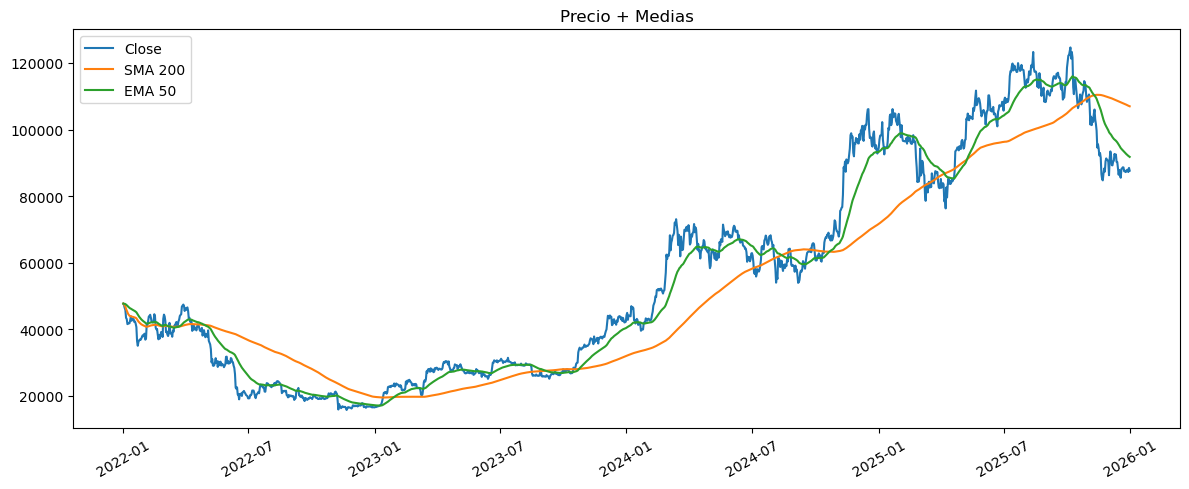

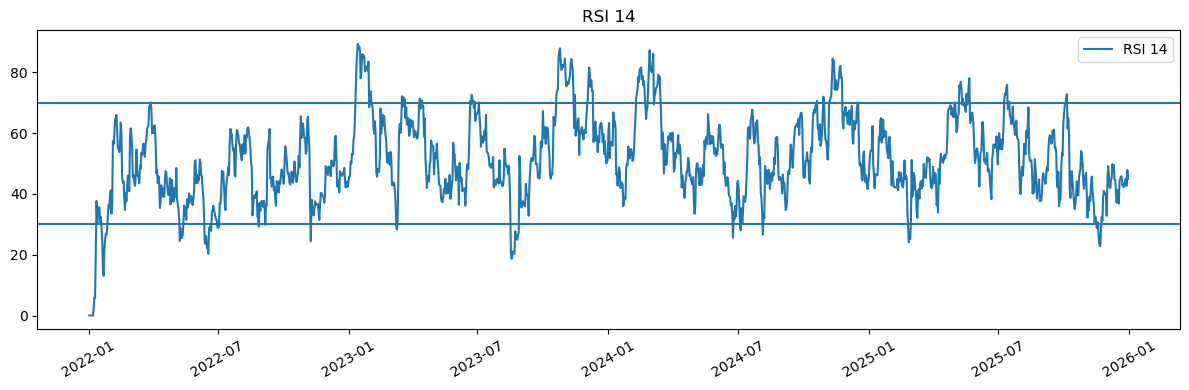

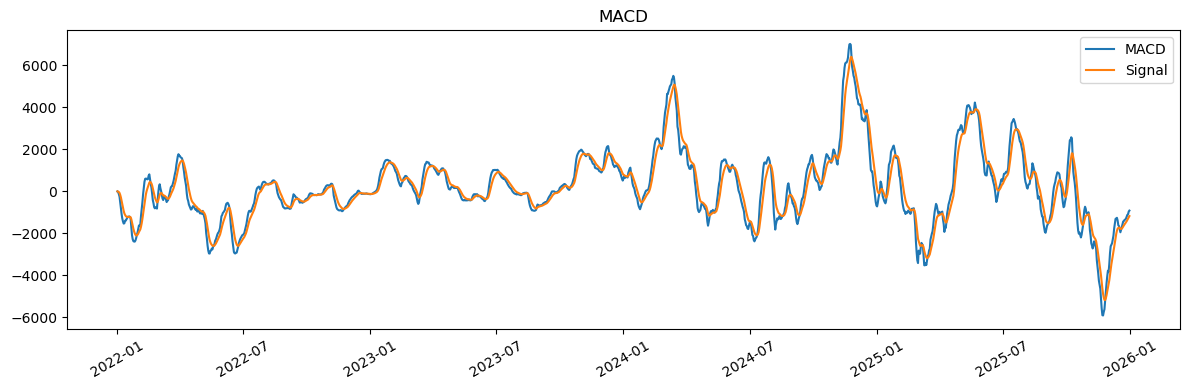

In [28]:
# ==============================
# VISUALIZACIÓN MÉTRICAS GOLD
# ==============================

from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

gold_path = "hdfs:///datos/gittba26/gittba03/oro"

# 1) Leer GOLD y filtrar
df_gold = spark.read.parquet(gold_path)

df_plot = (df_gold
    .orderBy("event_time")
    .select("event_time","close","sma_200","ema_50","rsi_14","macd","macd_signal")
)

# 2) Pasar a pandas
pdf = df_plot.toPandas()
pdf["event_time"] = pd.to_datetime(pdf["event_time"])

# ==============================
# 3) PRECIO + SMA200 + EMA50
# ==============================
plt.figure(figsize=(12,5))
plt.plot(pdf["event_time"], pdf["close"], label="Close")
plt.plot(pdf["event_time"], pdf["sma_200"], label="SMA 200")
plt.plot(pdf["event_time"], pdf["ema_50"], label="EMA 50")
plt.title("Precio + Medias")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ==============================
# 4) RSI 14
# ==============================
plt.figure(figsize=(12,4))
plt.plot(pdf["event_time"], pdf["rsi_14"], label="RSI 14")
plt.axhline(70)  # sobrecompra
plt.axhline(30)  # sobreventa
plt.title("RSI 14")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ==============================
# 5) MACD + SIGNAL
# ==============================
plt.figure(figsize=(12,4))
plt.plot(pdf["event_time"], pdf["macd"], label="MACD")
plt.plot(pdf["event_time"], pdf["macd_signal"], label="Signal")
plt.title("MACD")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()